In [15]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/reusable_codes')

from euler import euler


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## GROUP 13 Lab 04

Members :
   
Khushi Shah - 202401471

Tanish Sanghavi - 202401465

Sharvil Shah - 202401196

# PROBLEM 2: Limitation of Euler’s Method for Small Initial Conditions

We consider the nonlinear ordinary differential equation

$$
\dot{x} = a x^2 - b x^3
$$

with initial condition

$$
x(0) = \delta,
$$

where $\delta$ is a small positive parameter.

Given :
- $$a = 1$$ $$b = 1$$
- $$\delta = 0.1,\; 0.01,\; 0.001$$
- Integration interval: $$t \in [0, 1.5/\delta]$$

The goal is to observe how the solution evolves and to study the limitations of Euler’s method as $\delta$ becomes smaller.

In [ ]:
def nonlinear_system(t, y):
    x = y[0]
    return np.array([x**2 - x**3], dtype=float)

## Numerical Parameters

For each value of $\delta$, the integration time increases as 1/$\delta$.
To maintain numerical stability, the number of time steps is increased accordingly.

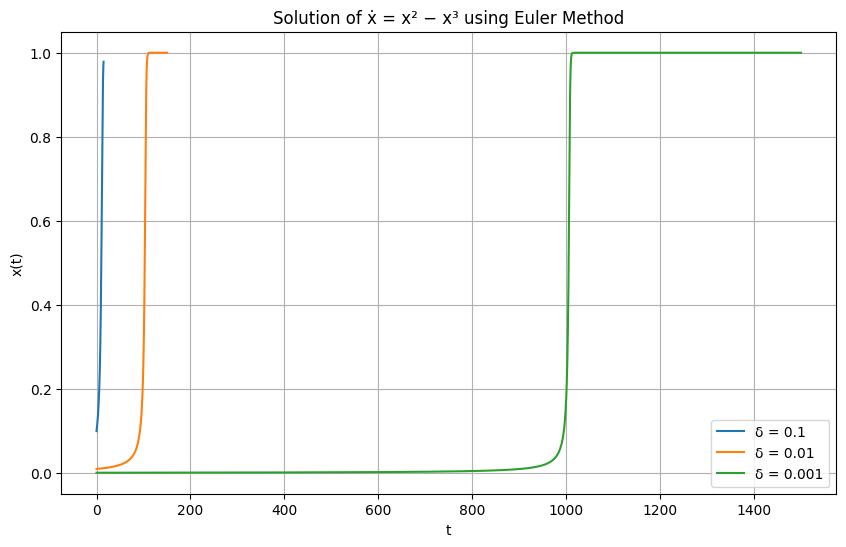

In [ ]:
deltas = [0.1, 0.01, 0.001]
step_counts = [2000, 8000, 30000]

plt.figure(figsize=(10, 6))

for delta, n in zip(deltas, step_counts):
    t_end = 1.5 / delta
    t = np.linspace(0, t_end, n)
    y0 = np.array([delta])

    sol = euler(nonlinear_system, y0, t)
    x = sol[:, 0]

    plt.plot(t, x, label=f"δ = {delta}")

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Solution of ẋ = x² − x³ using Euler Method")
plt.legend()
plt.grid(True)
plt.show()

## Observations

From the plotted solutions, we observe that for all values of δ, the solution $x(t)$ initially increases very slowly. This happens because the system starts from a very small initial value, and the growth term $x^2$ is extremely small at the beginning. After some time, the solution suddenly shows a sharp rise. This rapid increase occurs around $t \approx δ^{-1}$, meaning that smaller values of δ delay the onset of this sharp growth to later times. As δ becomes smaller, the transition from slow growth to fast growth becomes steeper, which is clearly visible as a sharper curve in the graph. Because this rapid change happens over a very short time interval, using the same step size for all values of δ is not sufficient. Euler’s method, being a first-order method with fixed step size, fails to capture this sudden change accurately, leading to numerical instability unless the step size is reduced.

## Why Must the Step Size Be Reduced?

Yes, the step size must be reduced as δ decreases.

Reason:
- The solution develops a **boundary-layer–like sharp transition**
- Euler’s method is a **first-order explicit method**
- Large steps cannot resolve rapid changes in the solution
- Errors accumulate and cause oscillations or artificial blow-up

As δ becomes smaller:
- The transition region becomes narrower
- Higher time resolution is required
- Hence, more subdivisions are necessary

## (b) Why does the sudden increase occur at $ t \sim \delta^{-1} $?

The sudden increase occurs around $ t \sim \delta^{-1} $ because of the way the solution evolves when starting from a very small initial condition. For the equation  
$$
\dot{x} = x^2 - x^3 = x^2(1 - x),
$$
when $ x $ is small (which is true initially since $ x(0)=\delta $, the dominant term is $ x^2 $. In this early stage, the growth rate $ \dot{x} $ is extremely small, so the solution increases very slowly. This creates a long “flat” region in the graph.

If we focus only on the dominant early-time behavior, the equation is approximately
$$
\dot{x} \approx x^2.
$$
Solving this simplified equation gives
$$
x(t) \approx \frac{\delta}{1 - \delta t}.
$$
From this expression, it is clear that the solution changes rapidly when the denominator $ 1 - \delta t $ becomes small, which happens when $ t $ is of order $\delta^{-1} $. This explains why the sharp increase (or ramp) always appears near t∼δ$^{−1}$, and why this point shifts to larger times as \( \delta \) decreases.

This behavior is closely related to what happens in the logistic equation
$$
\dot{x} = a x - b x^2,\quad x(0)=\delta.
$$
In the logistic equation, when  x  is very small, the linear term  ax dominates, and the solution grows exponentially. Changing $ \delta $ mainly shifts the solution vertically but does not significantly change the time at which the rapid growth (the ramp) occurs. In contrast, for the present equation, the leading growth term is $\ x^2 $, not $\ x $. As a result, the growth timescale explicitly depends on $\delta $, which is why the location of the sharp increase moves with $ \delta $.

Thus, the numerical observation that the sudden increase occurs at $\ t \sim \delta^{-1} $ has a clear theoretical explanation: it arises from the quadratic growth term dominating the dynamics when the solution starts from a very small initial value.

<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_903/3785775369.py:28: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Verification of sudden increase at t $\sim \delta^{-1}$")


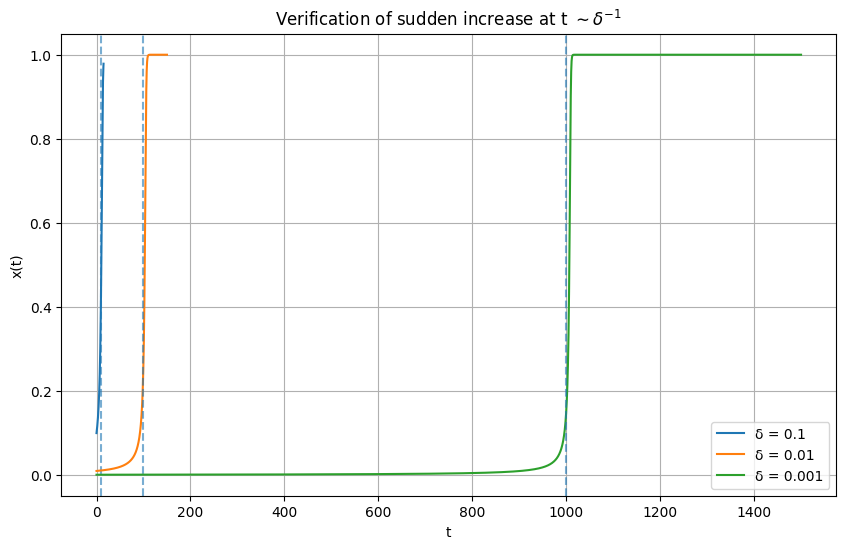

In [ ]:
from euler import euler

# Given equation: dx/dt = x^2 - x^3
def f(t, y):
    return np.array([y[0]**2 - y[0]**3])

deltas = [0.1, 0.01, 0.001]

plt.figure(figsize=(10, 6))

for delta in deltas:
    t_end = 1.5 / delta
    n = 5000
    t = np.linspace(0, t_end, n)

    y0 = np.array([delta])

    sol = euler(f, y0, t)
    x = sol[:, 0]

    plt.plot(t, x, label=f"δ = {delta}")

    # Mark t = 1/delta
    plt.axvline(x=1/delta, linestyle='--', alpha=0.6)

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Verification of sudden increase at t $\sim \delta^{-1}$")
plt.legend()
plt.grid(True)
plt.show()